In [5]:
import pandas as pd

# Load the dataset
file_path = './data_india_ENRG.xlsx' 
data = pd.read_excel(file_path, sheet_name='Sheet1')

data['Combined Date'] = data['Year'].astype(str) + " " + data['Date']
data['Formatted Date'] = pd.to_datetime(data['Combined Date'], format='%Y %d-%b %I%p')

data['Datetime'] = data['Formatted Date'].dt.strftime('%d-%m-%Y %H:%M')

filtered_data = data[['Datetime', 'NA_MW']]

output_file_path = 'data_india_ENRG-2.xlsx' 
filtered_data.to_excel(output_file_path, index=False)

print(f"Filtered file saved as: {output_file_path}")


Filtered file saved as: data_india_ENRG-2.xlsx


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()

In [197]:
import xgboost
print(xgboost.__version__)

2.1.3


In [175]:
pip install xgboost --upgrade

Note: you may need to restart the kernel to use updated packages.


In [127]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 5.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 9.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
import xgboost as xgb

In [79]:
file_path = './data_india_ENRG-2.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

In [81]:
df.tail()

,Datetime,NA_MW
64243,30-04-2024 19:00,201094.24
64244,30-04-2024 20:00,196577.71
64245,30-04-2024 21:00,194782.12
64246,30-04-2024 22:00,194967.39
64247,30-04-2024 23:00,194194.45


In [83]:
df = df.set_index('Datetime')

In [85]:
df.head()

,NA_MW
Datetime,
01-01-2017 00:00,108985.17
01-01-2017 01:00,105856.08
01-01-2017 02:00,103115.75
01-01-2017 03:00,102407.04
01-01-2017 04:00,104235.34


In [87]:
df.index = pd.to_datetime(df.index, format='%d-%m-%Y %H:%M')

In [89]:
df

,NA_MW
Datetime,
2017-01-01 00:00:00,108985.17
2017-01-01 01:00:00,105856.08
2017-01-01 02:00:00,103115.75
2017-01-01 03:00:00,102407.04
2017-01-01 04:00:00,104235.34
...,...
2024-04-30 19:00:00,201094.24
2024-04-30 20:00:00,196577.71
2024-04-30 21:00:00,194782.12


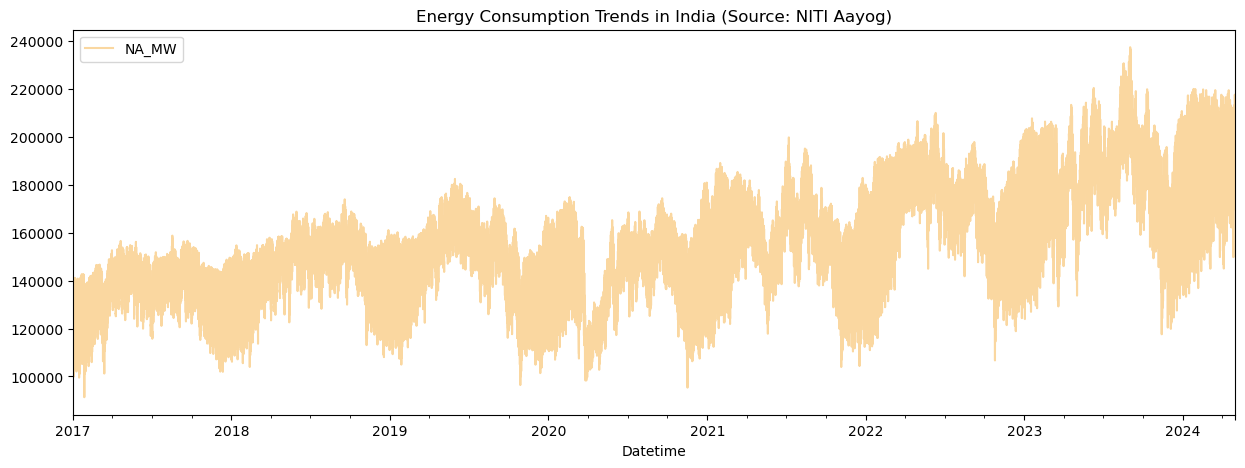

In [91]:
df.plot(
    style='-', 
    figsize=(15, 5),
    color='#FAD7A0',
    title='Energy Consumption Trends in India (Source: NITI Aayog)'
)
plt.show()

In [93]:
df.index

DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 01:00:00',
               '2017-01-01 02:00:00', '2017-01-01 03:00:00',
               '2017-01-01 04:00:00', '2017-01-01 05:00:00',
               '2017-01-01 06:00:00', '2017-01-01 07:00:00',
               '2017-01-01 08:00:00', '2017-01-01 09:00:00',
               ...
               '2024-04-30 14:00:00', '2024-04-30 15:00:00',
               '2024-04-30 16:00:00', '2024-04-30 17:00:00',
               '2024-04-30 18:00:00', '2024-04-30 19:00:00',
               '2024-04-30 20:00:00', '2024-04-30 21:00:00',
               '2024-04-30 22:00:00', '2024-04-30 23:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=64248, freq=None)

<Axes: ylabel='Frequency'>

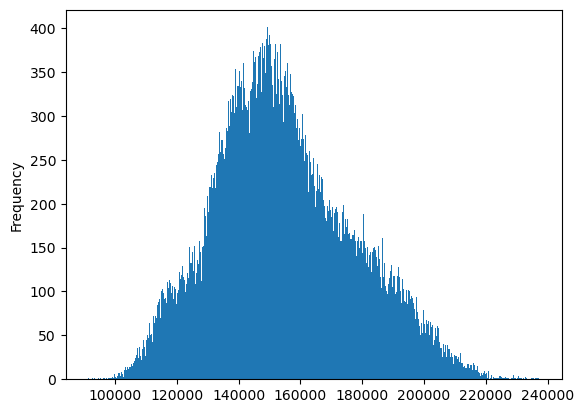

In [95]:
df['NA_MW'].plot(kind='hist', bins=500)

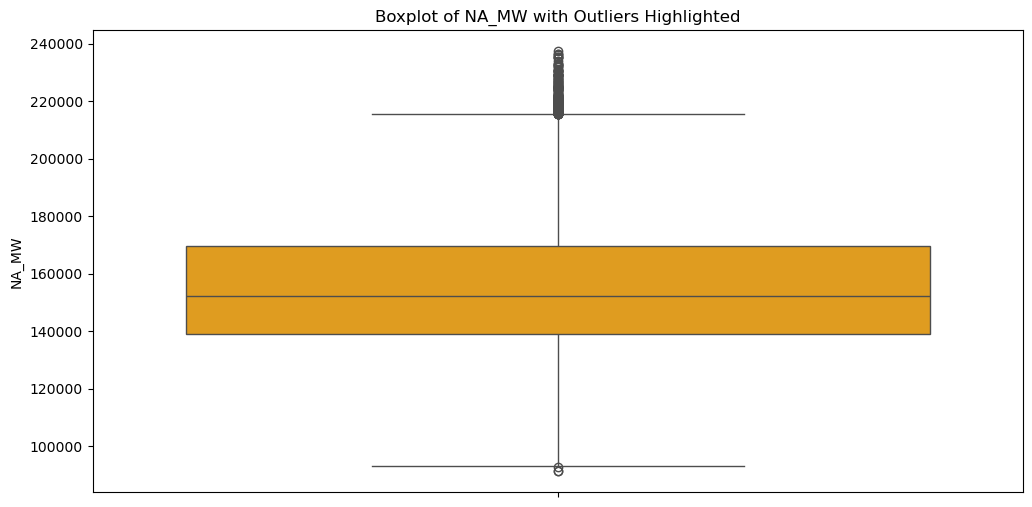

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df['NA_MW'], color='orange')
plt.title('Boxplot of NA_MW with Outliers Highlighted')
plt.show()

Original dataset size: 64248
Cleaned dataset size: 63994
Number of outliers removed: 254


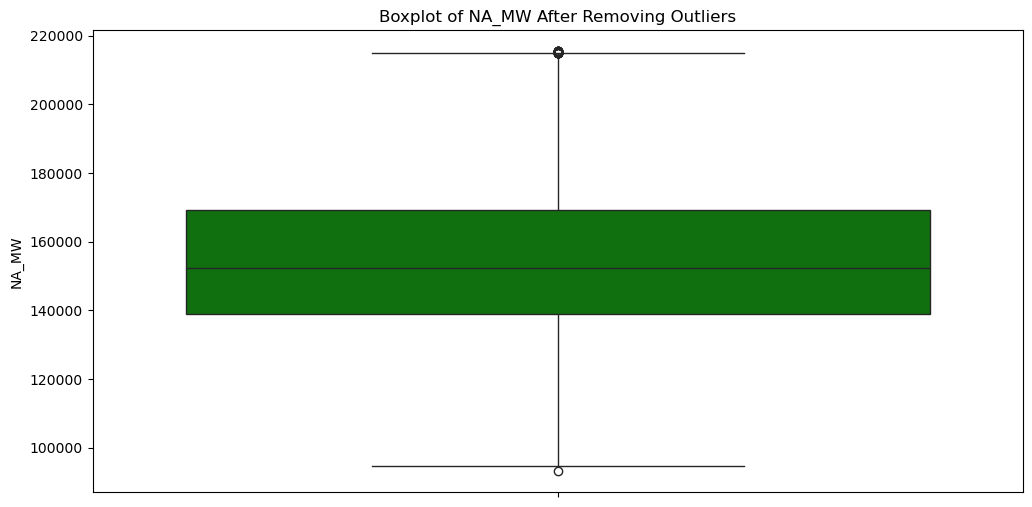

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['NA_MW'].quantile(0.25)
Q3 = df['NA_MW'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_cleaned = df[(df['NA_MW'] >= lower_bound) & (df['NA_MW'] <= upper_bound)]

# Print results
print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_cleaned)}")
print(f"Number of outliers removed: {len(df) - len(df_cleaned)}")

# Visualization of cleaned data
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned['NA_MW'], color='green')
plt.title('Boxplot of NA_MW After Removing Outliers')
plt.show()

In [109]:
df = df_cleaned

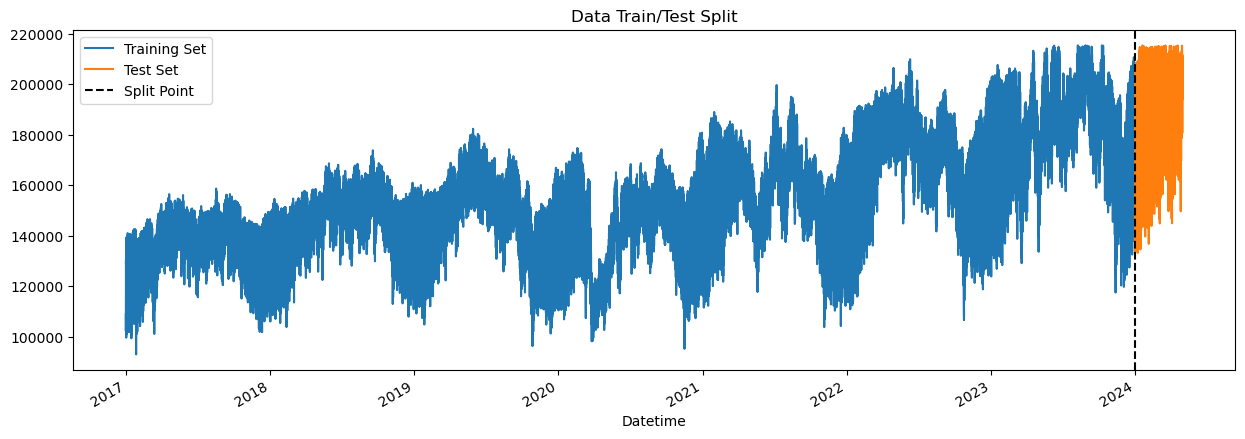

In [241]:
import pandas as pd
import matplotlib.pyplot as plt

cutoff_date = pd.to_datetime('2024-01-01')

train = df.loc[df.index < cutoff_date]
test = df.loc[df.index >= cutoff_date]

fig, ax = plt.subplots(figsize=(15, 5))
train['NA_MW'].plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test['NA_MW'].plot(ax=ax, label='Test Set')
ax.axvline(cutoff_date, color='black', linestyle='--', label='Split Point')
ax.legend(['Training Set', 'Test Set', 'Split Point'])
plt.show()

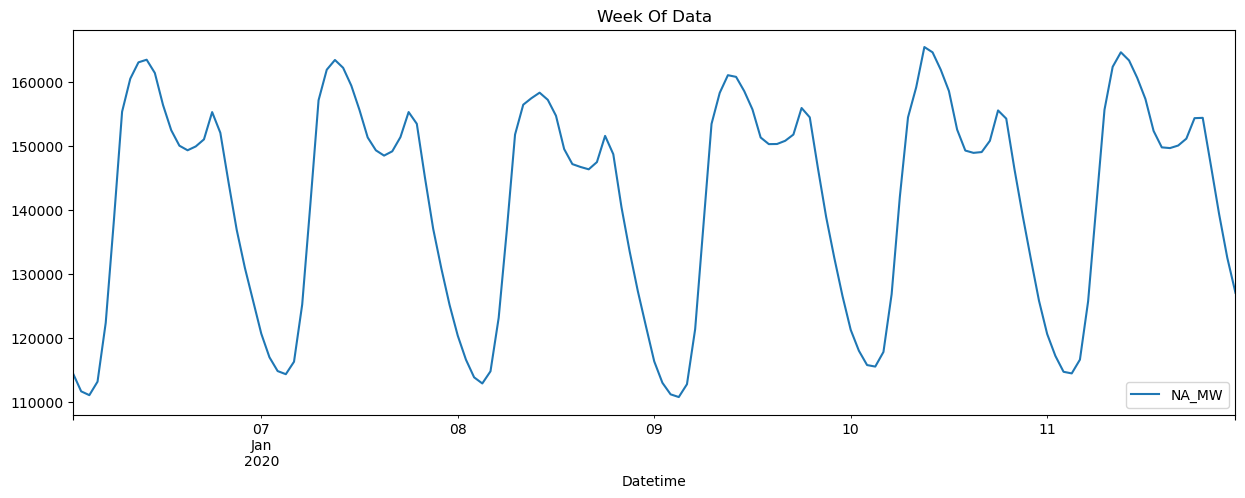

In [113]:
df.loc[(df.index > '01-06-2020') & (df.index < '01-12-2020')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()

In [231]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

In [233]:
df

,NA_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,prediction
Datetime,,,,,,,,,,
2017-01-01 00:00:00,108985.17,0,6,1,1,2017,1,1,52,NaN
2017-01-01 01:00:00,105856.08,1,6,1,1,2017,1,1,52,NaN
2017-01-01 02:00:00,103115.75,2,6,1,1,2017,1,1,52,NaN
2017-01-01 03:00:00,102407.04,3,6,1,1,2017,1,1,52,NaN
2017-01-01 04:00:00,104235.34,4,6,1,1,2017,1,1,52,103617.054688
...,...,...,...,...,...,...,...,...,...,...
2024-04-30 19:00:00,201094.24,19,1,2,4,2024,121,30,18,NaN
2024-04-30 20:00:00,196577.71,20,1,2,4,2024,121,30,18,NaN
2024-04-30 21:00:00,194782.12,21,1,2,4,2024,121,30,18,NaN


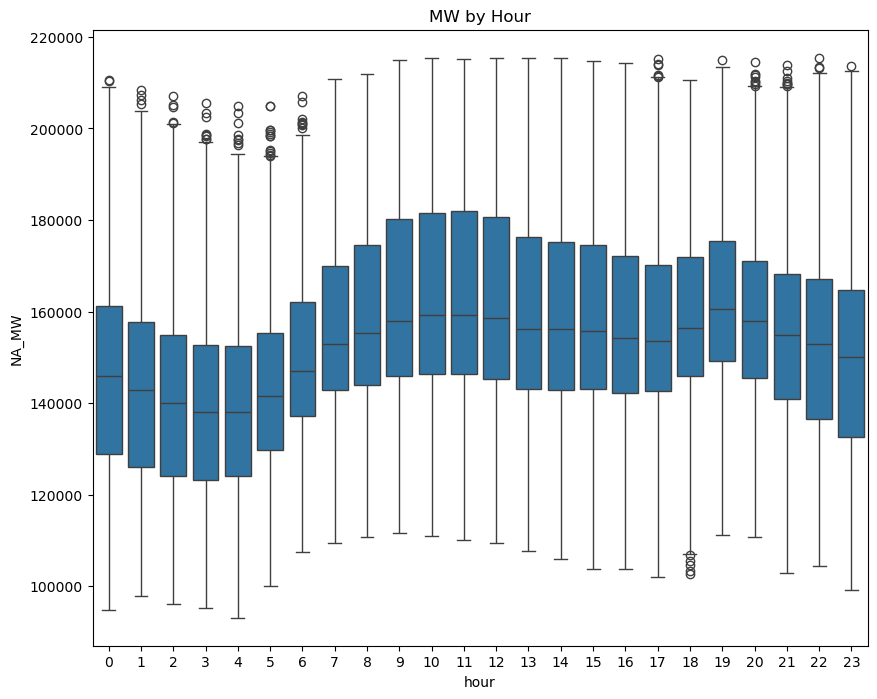

In [119]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='NA_MW')
ax.set_title('MW by Hour')
plt.show()

/var/folders/fx/2j6wthvx3ss0j55xgc1txl0m0000gn/T/ipykernel_19563/3811740319.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='NA_MW', palette='Blues')


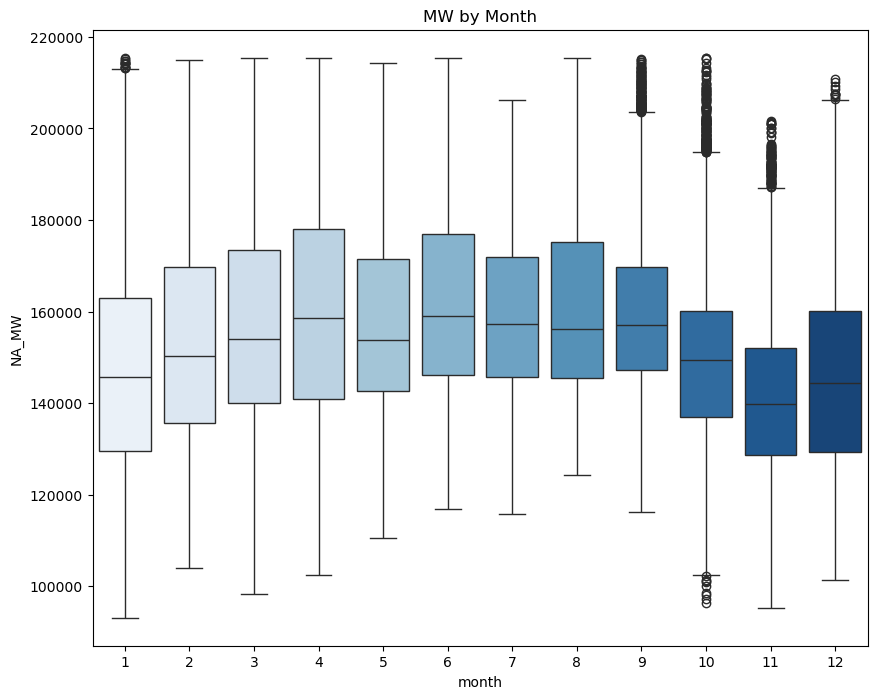

In [121]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='month', y='NA_MW', palette='Blues')
ax.set_title('MW by Month')
plt.show()

In [235]:
train = create_features(train)
test = create_features(test)

In [327]:
cutoff_date = pd.to_datetime('2024-02-02')
train = df[df.index < cutoff_date]  # All rows before 2024
test = df[df.index >= cutoff_date]  # All rows after or on 2024-01-01

# Print shapes to confirm
print(f"Train size: {train.shape}, Test size: {test.shape}")

# Ensure the 'test' data only contains years >= 2024
assert test.index.year.min() >= 2024, "Test data contains dates before 2024!"

Train size: (61901, 10), Test size: (2093, 10)


In [329]:
X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (61901, 6), y_train shape: (61901,)
X_test shape: (2093, 6), y_test shape: (2093,)


In [331]:
X_train,X_test

(                     hour  dayofweek  quarter  month  year  dayofyear
 Datetime                                                             
 2017-01-01 00:00:00     0          6        1      1  2017          1
 2017-01-01 01:00:00     1          6        1      1  2017          1
 2017-01-01 02:00:00     2          6        1      1  2017          1
 2017-01-01 03:00:00     3          6        1      1  2017          1
 2017-01-01 04:00:00     4          6        1      1  2017          1
 ...                   ...        ...      ...    ...   ...        ...
 2024-02-01 19:00:00    19          3        1      2  2024         32
 2024-02-01 20:00:00    20          3        1      2  2024         32
 2024-02-01 21:00:00    21          3        1      2  2024         32
 2024-02-01 22:00:00    22          3        1      2  2024         32
 2024-02-01 23:00:00    23          3        1      2  2024         32
 
 [61901 rows x 6 columns],
                      hour  dayofweek  quarter  

In [333]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Ensure the features and target are correctly set
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']
TARGET = 'NA_MW'

X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

# Define the objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 50.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 50.0),
        'random_state': 42,
        'objective': 'reg:squarederror'
    }

    # Train the model with the suggested hyperparameters
    model = XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    # Predict and calculate RMSE
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    return rmse

# Create the Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, n_jobs=-1)  # Perform tuning

# Display the best parameters
best_params = study.best_params
print("Best Parameters:", best_params)

# Final RMSE with the best parameters
final_model = XGBRegressor(**best_params)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Final RMSE: {final_rmse}")

Best Parameters: {'learning_rate': 0.03262174972785073, 'n_estimators': 643, 'max_depth': 3, 'min_child_weight': 10, 'colsample_bytree': 0.6735887654411089, 'subsample': 0.9475945835108492, 'gamma': 2.6730833749993432, 'reg_alpha': 44.47828141604356, 'reg_lambda': 15.798836316763719}
Final RMSE: 8886.143200512855


In [335]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Assuming best_params is already defined with your optimal hyperparameters
best_params.update({
    'objective': 'reg:squarederror',  # Objective for regression
    'random_state': 42,               # Ensures reproducibility
    'early_stopping_rounds': 50       # Early stopping after 50 rounds with no improvement
})

# Define the model with the best parameters
final_model = XGBRegressor(**best_params)

# Train the model with early stopping
final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],  # Training and validation dataset
    verbose=100                                      # Show logs every 100 rounds
)

# Evaluate the final model
y_pred = final_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Final RMSE on Test Set: {rmse}")

[0]	validation_0-rmse:21624.97581	validation_1-rmse:35803.13620
[100]	validation_0-rmse:10991.65925	validation_1-rmse:15240.28052
[200]	validation_0-rmse:9589.19421	validation_1-rmse:10862.49872
[300]	validation_0-rmse:8948.10758	validation_1-rmse:9137.05955
[400]	validation_0-rmse:8380.39670	validation_1-rmse:8779.58734
[500]	validation_0-rmse:7955.16298	validation_1-rmse:8607.31216
[575]	validation_0-rmse:7719.21184	validation_1-rmse:8610.29844
Final RMSE on Test Set: 8594.538008083684


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


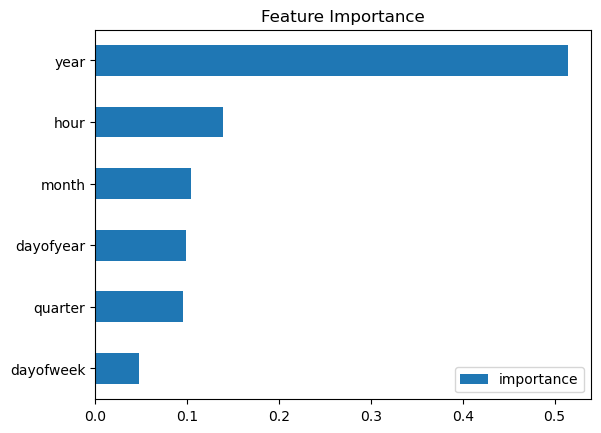

In [337]:
import pandas as pd
import matplotlib.pyplot as plt

# Access feature importances
fi = pd.DataFrame(data=final_model.feature_importances_,
                  index=final_model.feature_names_in_,
                  columns=['importance'])

# Plot feature importances
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

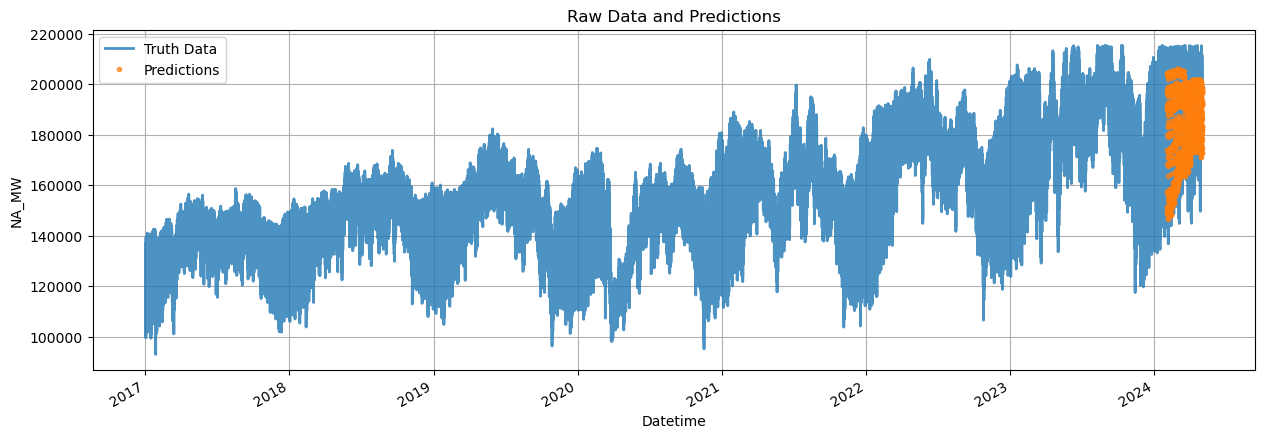

In [339]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have a DataFrame `df` with the target column `NA_MW`

# Generate predictions for the test data
test_predictions = pd.DataFrame({
    'prediction': final_model.predict(X_test)  # Predict using your trained model
}, index=X_test.index)  # Ensure the index matches X_test

# Merge predictions into your original DataFrame (assuming `df` has the correct index)
df['prediction'] = test_predictions['prediction']

# Plot actual values and predictions
ax = df[['NA_MW']].plot(figsize=(15, 5), linewidth=2, alpha=0.8, label='Truth Data')
df['prediction'].plot(ax=ax, style='.', alpha=0.7, label='Predictions')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Data and Predictions')
ax.set_xlabel('Datetime')  # Update this if your index represents datetime
ax.set_ylabel('NA_MW')
plt.grid()
plt.show()

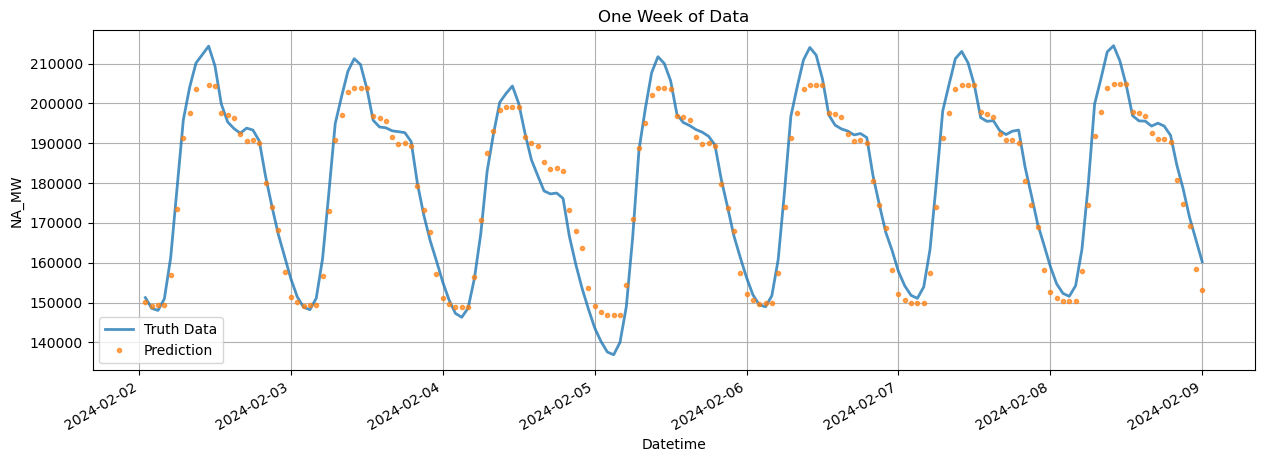

In [345]:
# Filter data for a specific week
ax = df.loc[(df.index > '2024-02-02') & (df.index <= '2024-02-09'), 'NA_MW'] \
    .plot(figsize=(15, 5), title='One Week of Data', linewidth=2, alpha=0.8)

# Plot predictions for the same week
df.loc[(df.index > '2024-02-02') & (df.index <= '2024-02-09'), 'prediction'] \
    .plot(ax=ax, style='.', alpha=0.7)

# Add legend and labels
plt.legend(['Truth Data', 'Prediction'])
plt.xlabel('Datetime')
plt.ylabel('NA_MW')
plt.grid()
plt.show()

In [347]:
score = np.sqrt(mean_squared_error(test['NA_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 9646.07


In [351]:
# Calculate the absolute error for each prediction
test['error'] = np.abs(test[TARGET] - test['prediction'])

# Group by date and calculate the mean error for each date
daily_mean_error = (
    test.groupby(test.index.date)['error']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Display the top 10 dates with the highest mean error
print(daily_mean_error)

2024-04-25    22752.546875
2024-04-03    21302.230573
2024-03-29    15665.256563
2024-03-30    14597.274010
2024-03-28    13798.297422
2024-04-29    13780.687159
2024-04-28    13671.063255
2024-04-02    13658.534010
2024-04-04    13099.801406
2024-04-26    12528.340625
Name: error, dtype: float64


/var/folders/fx/2j6wthvx3ss0j55xgc1txl0m0000gn/T/ipykernel_19563/3565694536.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['error'] = np.abs(test[TARGET] - test['prediction'])


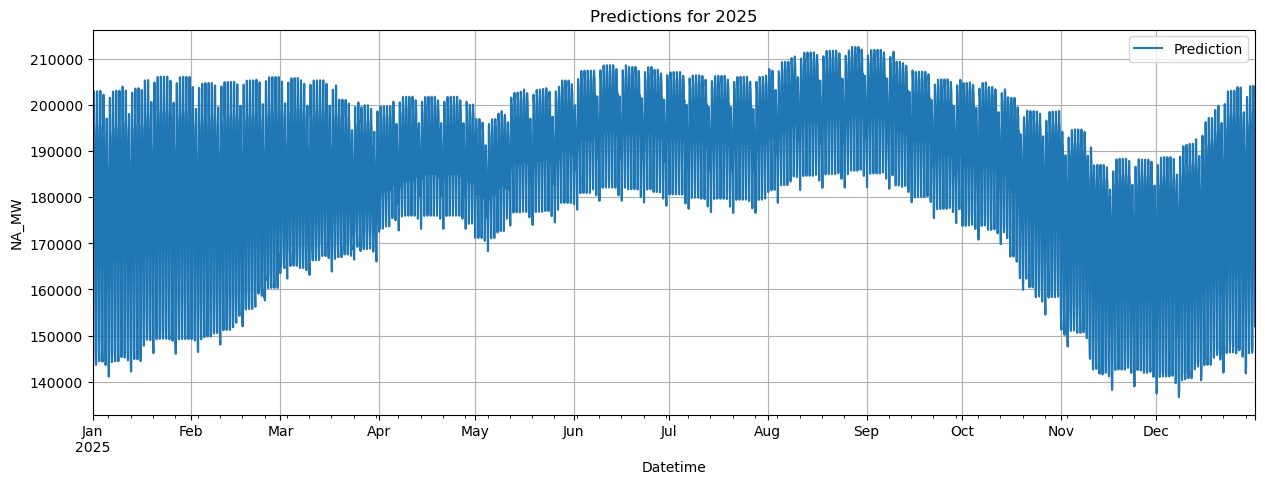

                     hour  dayofweek  quarter  month  year  dayofyear  \
2025-01-01 00:00:00     0          2        1      1  2025          1   
2025-01-01 01:00:00     1          2        1      1  2025          1   
2025-01-01 02:00:00     2          2        1      1  2025          1   
2025-01-01 03:00:00     3          2        1      1  2025          1   
2025-01-01 04:00:00     4          2        1      1  2025          1   

                        prediction  
2025-01-01 00:00:00  145816.437500  
2025-01-01 01:00:00  144474.265625  
2025-01-01 02:00:00  143633.359375  
2025-01-01 03:00:00  143872.687500  
2025-01-01 04:00:00  143872.687500  


In [361]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Existing features used in the model
FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'NA_MW'

# Step 1: Create a Datetime Index for the future (2025–2026)
future_dates = pd.date_range(start='2025-01-01', end='2026-12-31', freq='h')  # Note 'h' for hourly
future_df = pd.DataFrame(index=future_dates)

# Step 2: Generate features for the future data
future_df['hour'] = future_df.index.hour
future_df['dayofweek'] = future_df.index.dayofweek
future_df['quarter'] = future_df.index.quarter
future_df['month'] = future_df.index.month
future_df['year'] = future_df.index.year
future_df['dayofyear'] = future_df.index.dayofyear

# Step 3: Extract the feature matrix for predictions
X_future = future_df[FEATURES]

# Ensure feature order matches the trained model
trained_features = final_model.get_booster().feature_names
X_future = X_future[trained_features]  # Reorder columns to match trained model

# Step 4: Predict using the trained model
future_df['prediction'] = final_model.predict(X_future)

# Step 5: Visualize predictions for 2025
ax = future_df['2025-01-01':'2025-12-31']['prediction'] \
    .plot(figsize=(15, 5), title='Predictions for 2025')
plt.legend(['Prediction'])
plt.xlabel('Datetime')
plt.ylabel('NA_MW')
plt.grid()
plt.show()

# Step 6: Inspect future_df for validation
print(future_df.head())

# this is another model lightbgm

In [365]:
pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.0 MB/s eta 0:00:0000:010:01
Note: you may need to restart the kernel to use updated packages.


[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 307
[LightGBM] [Info] Number of data points in the train set: 61901, number of used features: 6
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Start training from score 153489.278471
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[125]	valid_0's rmse: 9238.39	valid_0's l2: 8.53479e+07
Final RMSE on Test Set: 9238.391453285762


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/var/folders/fx/2j6wthvx3ss0j55xgc1txl0m0000gn/T/ipykernel_19563/2564717218.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = y_pred


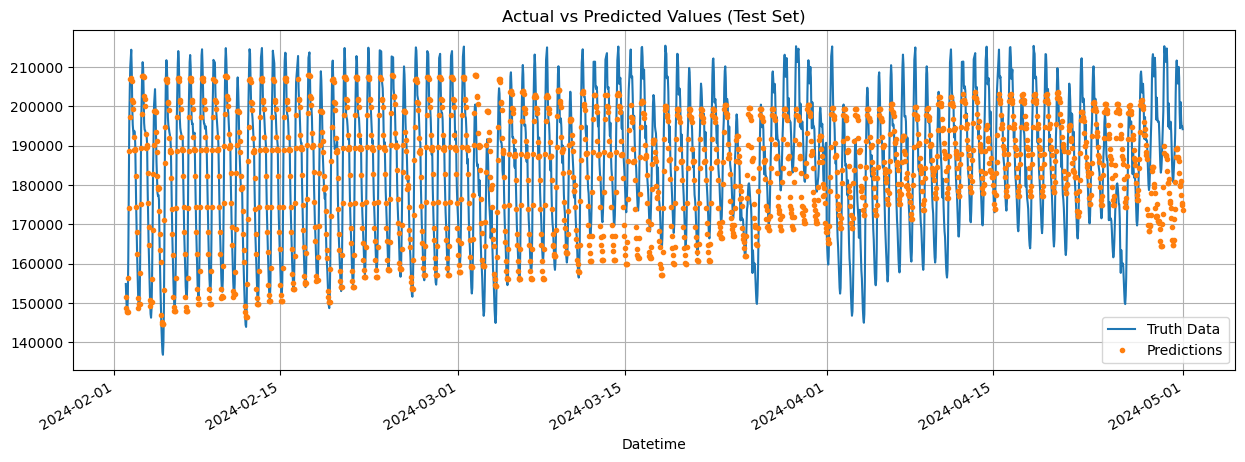

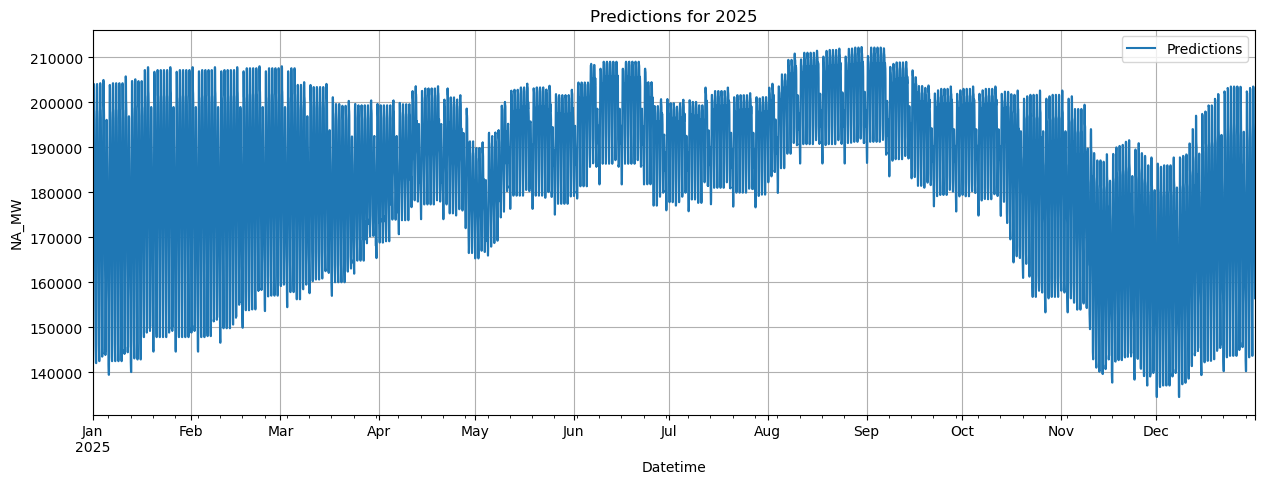

                     hour  dayofweek  quarter  month  year  dayofyear  \
2025-01-01 00:00:00     0          2        1      1  2025          1   
2025-01-01 01:00:00     1          2        1      1  2025          1   
2025-01-01 02:00:00     2          2        1      1  2025          1   
2025-01-01 03:00:00     3          2        1      1  2025          1   
2025-01-01 04:00:00     4          2        1      1  2025          1   

                        prediction  
2025-01-01 00:00:00  145848.261943  
2025-01-01 01:00:00  143008.193414  
2025-01-01 02:00:00  142096.665303  
2025-01-01 03:00:00  142044.613885  
2025-01-01 04:00:00  142044.613885  


In [375]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

# Define the features and target
FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'NA_MW'

# Assuming `train` and `test` are already defined
X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

# Step 1: Train a LightGBM model
lgbm_params = {
    'objective': 'regression',       # Regression task
    'random_state': 42,              # Ensures reproducibility
    'learning_rate': 0.05,           # Learning rate
    'n_estimators': 1000,            # Number of boosting rounds
    'max_depth': 7,                  # Max depth of each tree
    'num_leaves': 31,                # Number of leaves in a tree
    'early_stopping_rounds': 50      # Stop training if validation doesn't improve
}

lgbm_model = LGBMRegressor(**lgbm_params)

# Train the model with early stopping
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],     # Validation set
    eval_metric='rmse'             # Evaluation metric
)

# Step 2: Evaluate the final model
y_pred = lgbm_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Final RMSE on Test Set: {rmse}")

# Step 3: Add predictions to the test set for visualization
test['prediction'] = y_pred

# Visualize predictions vs actual values
ax = test[['NA_MW']].plot(figsize=(15, 5), title='Actual vs Predicted Values (Test Set)')
test['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
plt.grid()
plt.show()

# Step 4: Create future predictions (2025-2026)
future_dates = pd.date_range(start='2025-01-01', end='2026-12-31', freq='h')
future_df = pd.DataFrame(index=future_dates)

# Generate features for future dates
future_df['hour'] = future_df.index.hour
future_df['dayofweek'] = future_df.index.dayofweek
future_df['quarter'] = future_df.index.quarter
future_df['month'] = future_df.index.month
future_df['year'] = future_df.index.year
future_df['dayofyear'] = future_df.index.dayofyear

# Predict future values
X_future = future_df[FEATURES]
future_df['prediction'] = lgbm_model.predict(X_future)

# Visualize predictions for 2025
ax = future_df['2025-01':'2025-12']['prediction'].plot(figsize=(15, 5), title='Predictions for 2025')
plt.legend(['Predictions'])
plt.xlabel('Datetime')
plt.ylabel('NA_MW')
plt.grid()
plt.show()

# (Optional) Display the first few rows of the future predictions
print(future_df.head())

# fb prophet

In [381]:
pip install prophet

  Using cached holidays-0.62-py3-none-any.whl.metadata (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 28.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 9.9 MB/s eta 0:00:00
Using cached holidays-0.62-py3-none-any.whl (1.2 MB)
Note: you may need to restart the kernel to use updated packages.


23:10:58 - cmdstanpy - INFO - Chain [1] start processing
23:11:16 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/fx/2j6wthvx3ss0j55xgc1txl0m0000gn/T/ipykernel_19563/3577285300.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_additional = pd.date_range(start='2025-01-01', end='2026-12-31', freq='H')  # Add 2025-2026


Test RMSE: 13725.196900721357


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


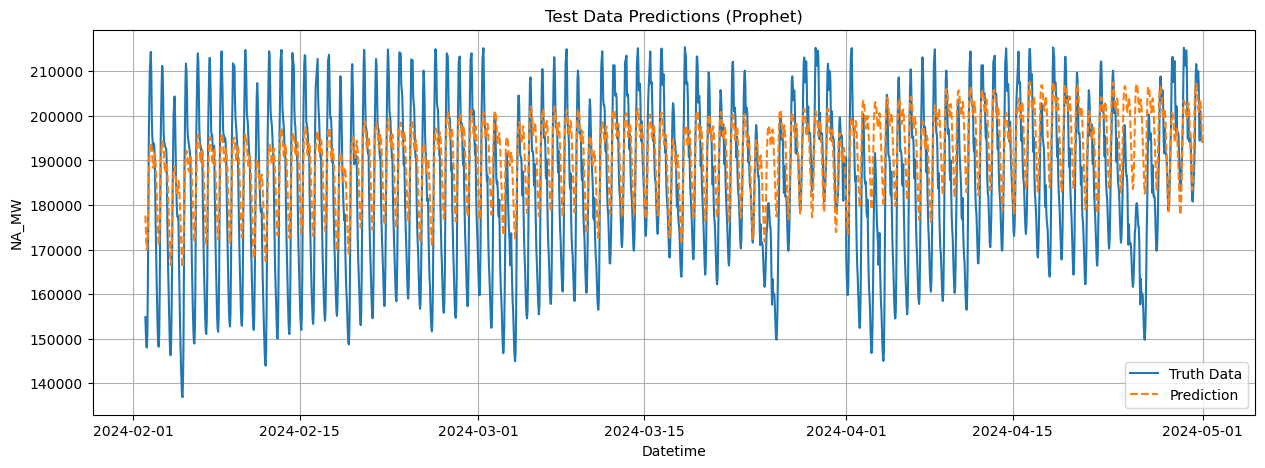

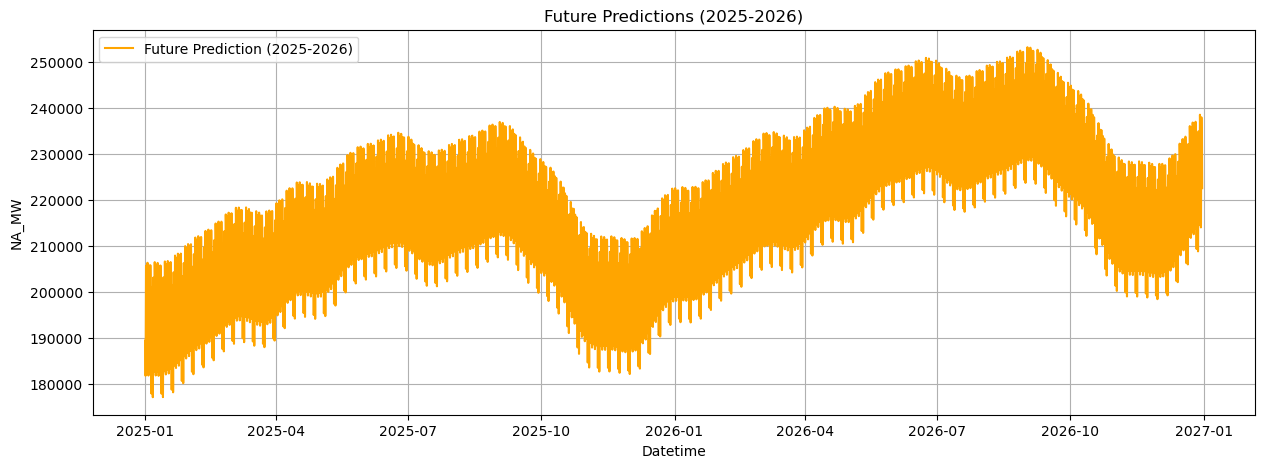

                      ds           yhat
2093 2025-01-01 00:00:00  189375.678111
2094 2025-01-01 01:00:00  186163.200871
2095 2025-01-01 02:00:00  183297.274768
2096 2025-01-01 03:00:00  181704.079571
2097 2025-01-01 04:00:00  182517.287487


In [383]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Step 1: Prepare the training and test datasets for Prophet
# Prophet requires columns 'ds' for datetime and 'y' for target
train_prophet = train.reset_index()[['Datetime', 'NA_MW']].rename(columns={'Datetime': 'ds', 'NA_MW': 'y'})
test_prophet = test.reset_index()[['Datetime', 'NA_MW']].rename(columns={'Datetime': 'ds', 'NA_MW': 'y'})

# Step 2: Initialize and train the Prophet model
prophet_model = Prophet()  # Add seasonalities if necessary (e.g., daily, yearly)
prophet_model.fit(train_prophet)

# Step 3: Create a dataframe for future predictions (test + additional future dates)
# Use the existing test set and extend it for future predictions (2025-2026)
future_dates = test_prophet[['ds']].copy()  # Start with test dates
future_additional = pd.date_range(start='2025-01-01', end='2026-12-31', freq='H')  # Add 2025-2026
future_additional_df = pd.DataFrame({'ds': future_additional})

# Combine test dates and future additional dates
future_df = pd.concat([future_dates, future_additional_df]).drop_duplicates().reset_index(drop=True)

# Step 4: Predict on the test set and future dates
forecast = prophet_model.predict(future_df)

# Step 5: Evaluate the model on the test set
# Join the test set with predictions
test_with_predictions = test_prophet.merge(forecast[['ds', 'yhat']], on='ds', how='left')
test_rmse = mean_squared_error(test_with_predictions['y'], test_with_predictions['yhat'], squared=False)
print(f"Test RMSE: {test_rmse}")

# Step 6: Visualize the test predictions
plt.figure(figsize=(15, 5))
plt.plot(test_with_predictions['ds'], test_with_predictions['y'], label='Truth Data')
plt.plot(test_with_predictions['ds'], test_with_predictions['yhat'], label='Prediction', linestyle='dashed')
plt.legend()
plt.title('Test Data Predictions (Prophet)')
plt.xlabel('Datetime')
plt.ylabel('NA_MW')
plt.grid()
plt.show()

# Step 7: Visualize future predictions for 2025-2026
future_forecast = forecast[forecast['ds'] >= '2025-01-01']  # Filter for future predictions
plt.figure(figsize=(15, 5))
plt.plot(future_forecast['ds'], future_forecast['yhat'], label='Future Prediction (2025-2026)', color='orange')
plt.title('Future Predictions (2025-2026)')
plt.xlabel('Datetime')
plt.ylabel('NA_MW')
plt.legend()
plt.grid()
plt.show()

# Step 8: Display the first few rows of future predictions
print(future_forecast[['ds', 'yhat']].head())